# VIIRS Nightfire — Gulf States Gas Flares (Oct 2022 – Jun 2023)

Recreating [VNF v4.0](https://eogdata.mines.edu/products/vnf/vnf_v40.html) using FIRMS VIIRS data + Planck curve fitting.

**Output:**
1. Time series — monthly flare count by temperature class (Low < 1000K, Medium 1000–1450K, High > 1450K) + flare volume (BCF)
2. Map — high-temperature signatures (> 1450K) for 1–7 Jun 2023
3. Final GPKG database

In [32]:
import io, time, warnings
from datetime import datetime, timedelta
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#333", "text.color": "#c9d1d9",
    "axes.labelcolor": "#c9d1d9", "xtick.color": "#8b949e",
    "ytick.color": "#8b949e", "figure.dpi": 130, "font.size": 10,
})

# ── Physical constants ──
_h  = 6.62607015e-34
_c  = 2.99792458e8
_kB = 1.380649e-23
_sigma = 5.670374419e-8
LAM_I4 = 3.74e-6   # VIIRS I4 (MWIR)
LAM_I5 = 11.45e-6  # VIIRS I5 (LWIR)
PIXEL_AREA = 375.0 * 375.0  # m²


def _planck(lam, T):
    """Planck radiance B(λ,T) in W/m²/sr/µm."""
    T = np.asarray(T, dtype=float)
    x = np.clip(_h * _c / (lam * _kB * T), 0, 500)
    return (2 * _h * _c**2 / lam**5) / (np.exp(x) - 1) * 1e-6


def estimate_fire_params(T4, T5, FRP):
    """
    FRP-constrained Dozier method for FIRMS brightness temps (fully vectorized).
    
    Uses I4 excess radiance + FRP as dual constraints to solve for
    fire temperature and sub-pixel area.
    
    R(Tf) = (Tf⁴ - Tbg⁴) / [B4(Tf) - B4(Tbg)]  must equal
    R_target = FRP / (σ * L4_exc * pixel_area)
    
    Finds closest-match Tf from a grid. Processes in chunks to manage memory.
    Returns: Tf (K), Area (m²)
    """
    T4 = np.asarray(T4, dtype=float)
    T5 = np.asarray(T5, dtype=float)
    FRP_w = np.asarray(FRP, dtype=float) * 1e6  # MW -> W
    
    L4_obs = _planck(LAM_I4, T4)
    L4_bg  = _planck(LAM_I4, T5)
    L4_exc = L4_obs - L4_bg
    
    n = len(T4)
    Tf_out = np.full(n, np.nan)
    Af_out = np.full(n, 0.0)
    
    valid = L4_exc > 0
    R_target = np.where(valid, FRP_w / (_sigma * L4_exc * PIXEL_AREA), 0)
    
    # Temperature grid
    T_grid = np.linspace(400, 3000, 500)
    B4_grid = np.array([_planck(LAM_I4, t) for t in T_grid])
    
    # Process in chunks of 50K to avoid memory blow-up (500 x 372K = 186M floats)
    CHUNK = 50000
    for start in range(0, n, CHUNK):
        end = min(start + CHUNK, n)
        sl = slice(start, end)
        m = end - start
        
        v = valid[sl]
        if not v.any():
            continue
        
        # R_model: shape (500, chunk)
        L4_bg_chunk = L4_bg[sl]  # (chunk,)
        T5_chunk = T5[sl]
        
        # Broadcasting: B4_grid[:,None] - L4_bg_chunk[None,:]  -> (500, chunk)
        denom = B4_grid[:, None] - L4_bg_chunk[None, :]  # (500, chunk)
        
        # (Tf^4 - T5^4): T_grid[:,None]^4 - T5_chunk[None,:]^4
        T4_diff = T_grid[:, None]**4 - T5_chunk[None, :]**4  # (500, chunk)
        
        R_model = np.where(denom > 0, T4_diff / denom, 1e20)  # (500, chunk)
        
        # Find best Tf per pixel
        R_target_chunk = R_target[sl]  # (chunk,)
        diffs = np.abs(R_model - R_target_chunk[None, :])  # (500, chunk)
        best_j = np.argmin(diffs, axis=0)  # (chunk,)
        
        Tf_best = T_grid[best_j]  # (chunk,)
        B4_best = B4_grid[best_j]  # (chunk,)
        denom_best = B4_best - L4_bg_chunk
        L4_exc_chunk = L4_exc[sl]
        
        p = np.where(denom_best > 0, L4_exc_chunk / denom_best, 0)
        good = v & (p > 1e-8) & (p < 1.0)
        
        Tf_out[sl] = np.where(good, Tf_best, np.nan)
        Af_out[sl] = np.where(good, p * PIXEL_AREA, 0.0)
    
    return Tf_out, Af_out

print("Engine ready.")

Engine ready.


## 1. Configuration

In [33]:
FIRMS_MAP_KEY = "2b1c34df0e49ece7703e69e48ab89256"
FIRMS_BASE = "https://firms.modaps.eosdis.nasa.gov/api/area/csv"

START_DATE = "2022-10-01"
END_DATE   = "2023-06-07"

# Gulf states bbox (excludes Africa) — covers Persian Gulf region
GULF_BBOX = "44,16,60,36"

COUNTRY_BBOX = {
    "Kuwait":        (46.5, 28.5, 48.5, 30.1),
    "Iraq":          (38.8, 29.0, 48.6, 37.4),
    "Iran":          (44.0, 25.0, 63.3, 39.8),
    "Saudi Arabia":  (34.5, 16.3, 55.7, 32.2),
    "UAE":           (51.5, 22.6, 56.4, 26.1),
    "Qatar":         (50.7, 24.4, 51.7, 26.2),
    "Bahrain":       (50.3, 25.7, 50.8, 26.3),
    "Oman":          (51.8, 16.6, 59.8, 26.4),
    "Yemen":         (42.5, 12.1, 54.5, 19.0),
}

GPKG_PATH = Path("data/gulf_flares_vnf.gpkg")
GPKG_PATH.parent.mkdir(exist_ok=True)

print(f"Period: {START_DATE} to {END_DATE}")
print(f"BBOX:   {GULF_BBOX}")

Period: 2022-10-01 to 2023-06-07
BBOX:   44,16,60,36


## 2. Download VIIRS data (FIRMS API)

In [34]:
# Load pre-downloaded data (run run_download.py first if parquet doesn't exist)
RAW_PATH = Path("data/raw_gulf_oct22_oct23.parquet")

if RAW_PATH.exists():
    raw = pd.read_parquet(RAW_PATH)
    print(f"Loaded from parquet: {len(raw):,} rows")
else:
    # Inline download fallback (slow for 13 months)
    def fetch(source, bbox, date, days=1):
        url = f"{FIRMS_BASE}/{FIRMS_MAP_KEY}/{source}/{bbox}/{days}/{date}"
        r = requests.get(url, timeout=120)
        if r.status_code == 400: return pd.DataFrame()
        r.raise_for_status()
        t = r.text.strip()
        if not t or t.startswith("<!") or t.startswith("{"): return pd.DataFrame()
        return pd.read_csv(io.StringIO(t))

    sources = ["VIIRS_SNPP_SP", "VIIRS_NOAA20_SP"]
    s, e = datetime.strptime(START_DATE, "%Y-%m-%d"), datetime.strptime(END_DATE, "%Y-%m-%d")
    dfs, cur = [], s
    while cur <= e:
        chunk = min((e - cur).days + 1, 5)
        ds = cur.strftime("%Y-%m-%d")
        for src in sources:
            try:
                df = fetch(src, GULF_BBOX, ds, chunk)
                if not df.empty: dfs.append(df)
            except Exception as ex:
                print(f"  Error {ds}: {ex}")
            time.sleep(0.4)
        if cur.day <= 5:
            print(f"  {ds} ... {sum(len(d) for d in dfs):,} rows")
        cur += timedelta(days=chunk)
    raw = pd.concat(dfs, ignore_index=True)
    raw.columns = raw.columns.str.lower()
    raw.to_parquet(RAW_PATH, index=False)
    print(f"Downloaded & saved: {len(raw):,} rows")

print(f"Columns: {list(raw.columns)}")

Loaded from parquet: 502,025 rows
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


## 3. Filter + Planck curve fitting + temperature classification

In [35]:
# ── Filter: night-only, confidence n/h, FRP >= 0.5 MW ──
mask = (
    (raw["daynight"] == "N") &
    (raw["confidence"].str.lower().isin(["n", "h"])) &
    (raw["frp"] >= 0.5)
)
df = raw[mask].drop_duplicates(
    subset=["latitude", "longitude", "acq_date", "acq_time"], keep="first"
).copy()
print(f"Filtered: {len(raw):,} -> {len(df):,}")

# ── FRP-constrained Dozier fitting (vectorized) ──
print("Running Planck fitting...")
t0 = time.time()
df["Temp_primary"], df["Area_primary"] = estimate_fire_params(
    df["bright_ti4"].values, df["bright_ti5"].values, df["frp"].values
)
print(f"  Done in {time.time()-t0:.1f}s")

df["Temp_background"] = df["bright_ti5"]
df["RH_primary"] = df["frp"]

# ── Temperature class (Low / Medium / High) ──
df["Temp_class"] = "Low"
df.loc[df["Temp_primary"] >= 1000, "Temp_class"] = "Medium"
df.loc[df["Temp_primary"] >= 1450, "Temp_class"] = "High"

# ── Assign country via spatial join with Natural Earth boundaries ──
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
gulf_countries = list(COUNTRY_BBOX.keys())
gulf_borders = world[world["NAME"].isin(gulf_countries)][["NAME", "geometry"]].copy()
gulf_borders = gulf_borders.rename(columns={"NAME": "country"})

gdf_tmp = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)
gdf_tmp = gpd.sjoin(gdf_tmp, gulf_borders, how="inner", predicate="within")
df = gdf_tmp.drop(columns=["geometry", "index_right"]).copy()

df["acq_date"] = pd.to_datetime(df["acq_date"])
df["month"] = df["acq_date"].dt.to_period("M")

# ── Flare volume estimate (BCF) ──
# ~1,000 m³/day per MW FRP (Elvidge et al. 2015), 1 m³ = 35.3147 ft³
# Each detection ≈ 12h effective (2 passes/day)
df["flare_volume_mcf"] = df["RH_primary"] * 1000 * 35.3147 * 12 / 1e6  # MCF

print(f"\nGulf states: {len(df):,} detections")
print(f"Countries: {df['country'].value_counts().to_dict()}")
print(f"Temp classes: {df['Temp_class'].value_counts().to_dict()}")
print(f"Temp_primary: min={df['Temp_primary'].min():.0f}K, median={df['Temp_primary'].median():.0f}K, max={df['Temp_primary'].max():.0f}K")

Filtered: 502,025 -> 372,779
Running Planck fitting...
  Done in 2.8s

Gulf states: 328,094 detections
Countries: {'Iran': 168339, 'Iraq': 102988, 'Saudi Arabia': 29751, 'Oman': 18573, 'Kuwait': 6547, 'Qatar': 1875, 'Yemen': 21}
Temp classes: {'High': 175735, 'Low': 118626, 'Medium': 33733}
Temp_primary: min=400K, median=1531K, max=3000K


## 4. Time series — monthly flare count by country

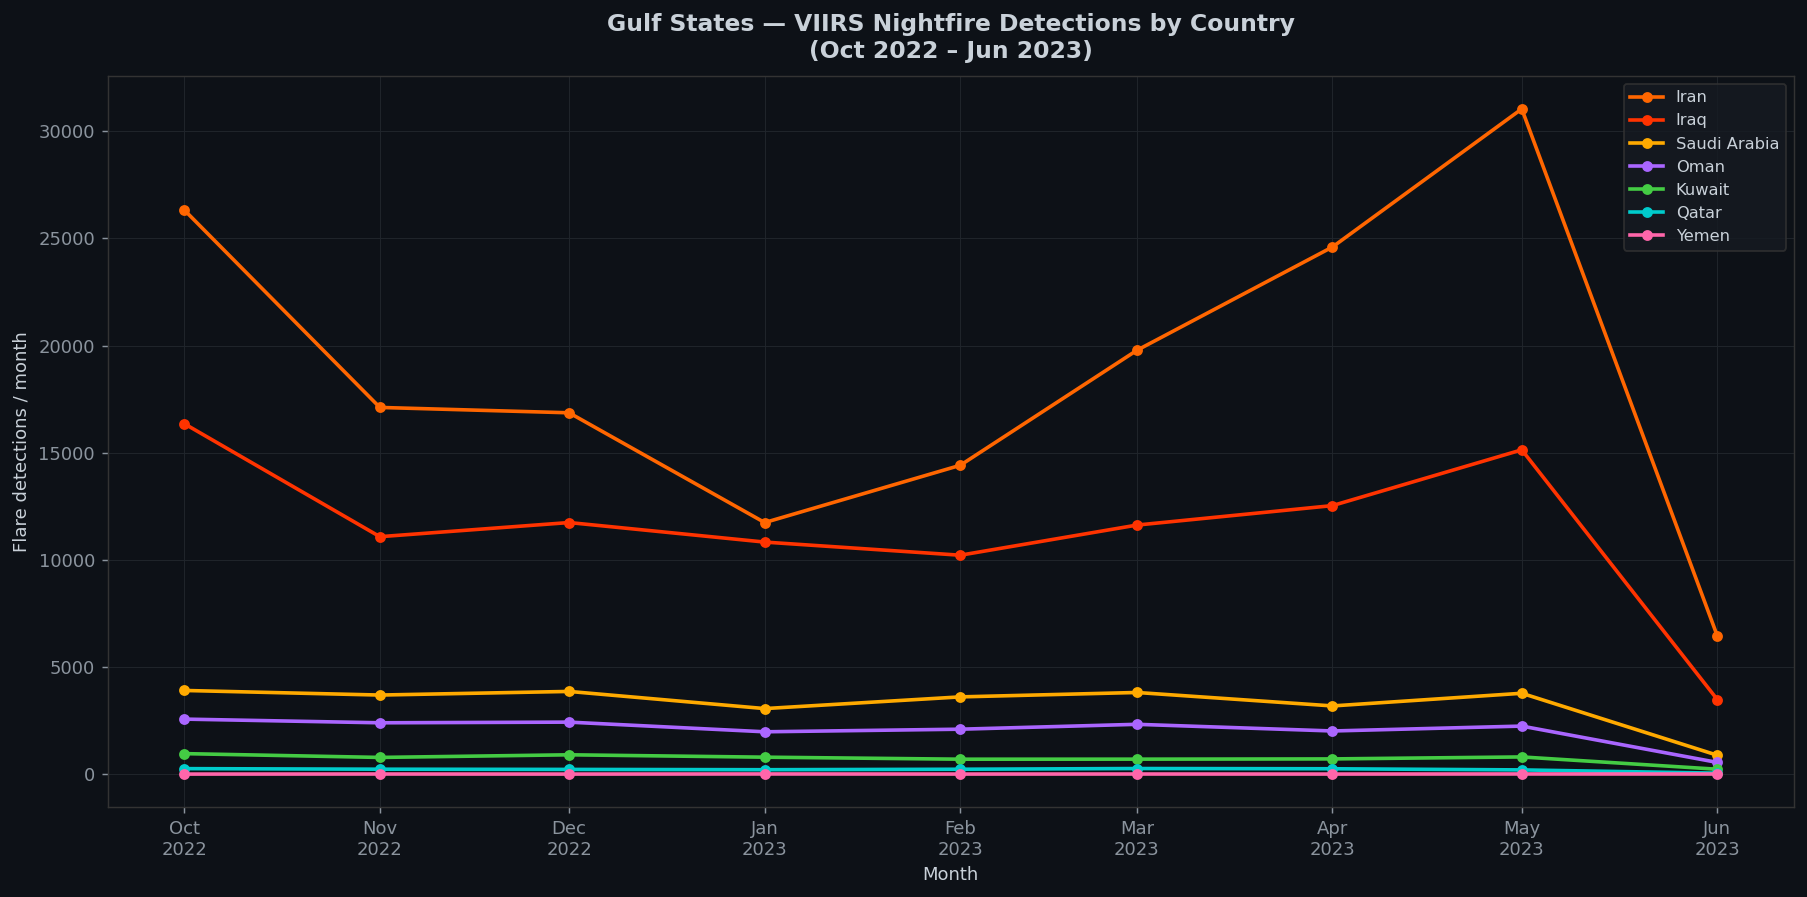

country,Iran,Iraq,Saudi Arabia,Oman,Kuwait,Qatar,Yemen
month,,,,,,,
2022-10-01,26331,16355,3903,2566,955,254,0
2022-11-01,17114,11081,3689,2394,777,228,3
2022-12-01,16864,11741,3858,2425,900,218,0
2023-01-01,11740,10829,3057,1974,789,204,5
2023-02-01,14413,10216,3603,2095,695,226,1
2023-03-01,19781,11623,3809,2323,697,259,3
2023-04-01,24604,12532,3181,2012,708,248,1
2023-05-01,31048,15135,3772,2240,800,195,5
2023-06-01,6444,3476,879,544,226,43,3


In [36]:
monthly_country = df.groupby(["month", "country"]).size().unstack(fill_value=0)
monthly_country.index = monthly_country.index.to_timestamp()

# Sort columns by total detections (descending)
monthly_country = monthly_country[monthly_country.sum().sort_values(ascending=False).index]

country_colors = {
    "Iraq": "#ff3300", "Iran": "#ff6600", "Saudi Arabia": "#ffaa00",
    "Kuwait": "#44cc44", "UAE": "#4488ff", "Oman": "#aa66ff",
    "Qatar": "#00cccc", "Yemen": "#ff66aa", "Bahrain": "#cccccc",
}

fig, ax = plt.subplots(figsize=(14, 7))

for country in monthly_country.columns:
    ax.plot(
        monthly_country.index, monthly_country[country],
        marker="o", markersize=5, linewidth=2,
        color=country_colors.get(country, "#888"),
        label=country,
    )

ax.set_ylabel("Flare detections / month")
ax.set_xlabel("Month")
ax.set_title("Gulf States — VIIRS Nightfire Detections by Country\n(Oct 2022 – Jun 2023)",
             fontsize=13, fontweight="bold", pad=10)
ax.legend(loc="upper right", fontsize=9, facecolor="#161b22", edgecolor="#333")
ax.grid(axis="both", color="#21262d", linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.savefig("data/timeseries_gulf_vnf.png", dpi=200, bbox_inches="tight")
plt.show()

monthly_country

## 5. Map — High temperature signatures (> 1450 K), 1–7 Jun 2023

High-temp detections 1-7 Jun 2023: 6948


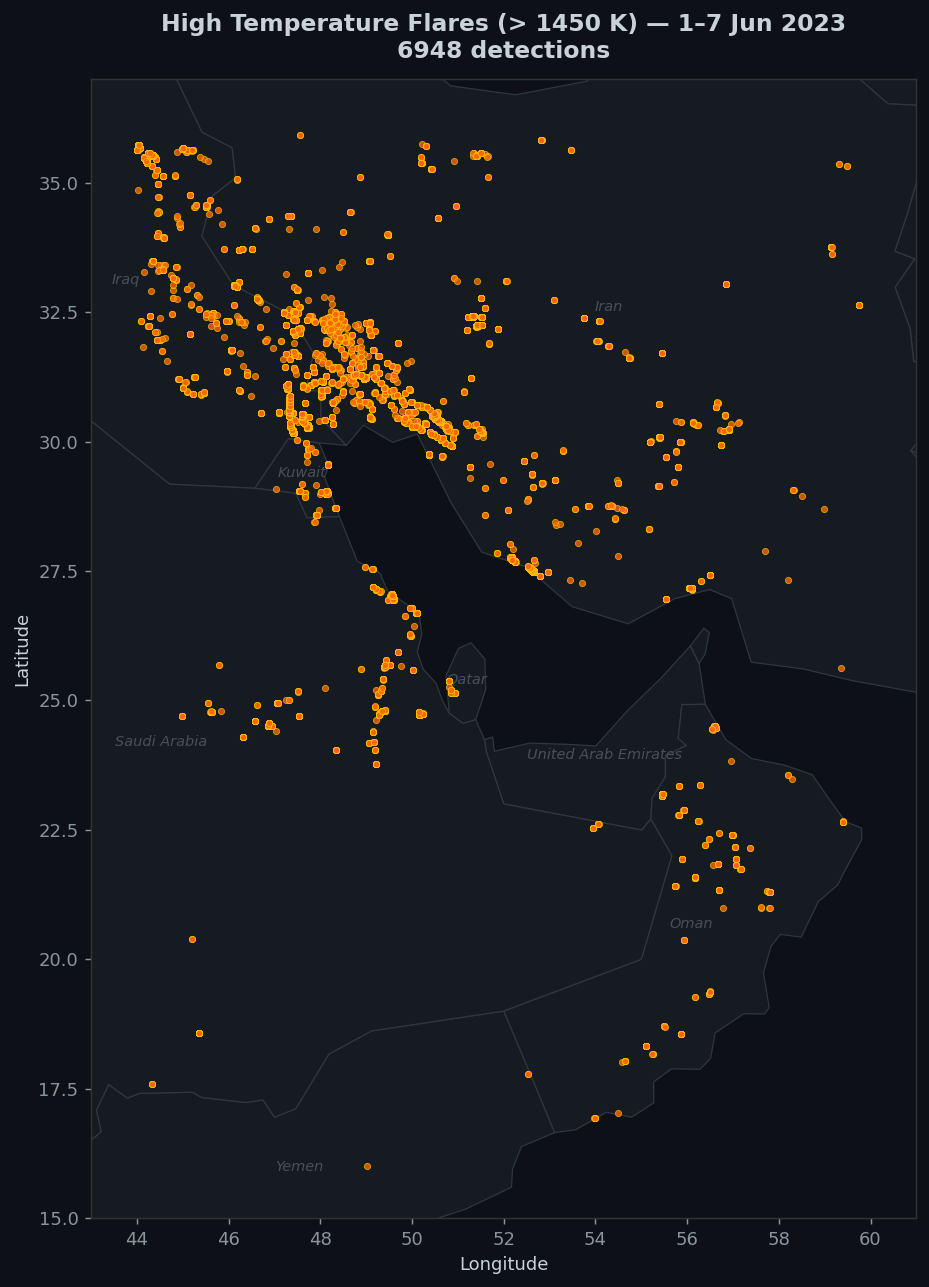

In [37]:
# Filter: high temp, 1-7 Jun 2023
hi = df[
    (df["Temp_class"] == "High") &
    (df["acq_date"] >= "2023-06-01") &
    (df["acq_date"] <= "2023-06-07")
].copy()
print(f"High-temp detections 1-7 Jun 2023: {len(hi)}")

# Reuse gulf_borders loaded in cell 3
gulf = world.cx[43:61, 15:37]

fig, ax = plt.subplots(figsize=(14, 10))

gulf.plot(ax=ax, color="#161b22", edgecolor="#30363d", linewidth=0.7)

# Country labels
for _, row in gulf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    if 43 < cx < 61 and 15 < cy < 37:
        ax.text(cx, cy, row["NAME"], fontsize=8, color="#484f58", ha="center", style="italic")

# High-temp points — equal size
if not hi.empty:
    ax.scatter(
        hi["longitude"], hi["latitude"],
        c="#ff6600", s=12, alpha=0.8,
        edgecolors="#ffcc00", linewidths=0.4, zorder=5,
    )

ax.set_xlim(43, 61)
ax.set_ylim(15, 37)
ax.set_title(f"High Temperature Flares (> 1450 K) — 1–7 Jun 2023\n{len(hi)} detections",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("data/map_high_temp_jun2023.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Save to GeoPackage

In [38]:
# Build final GeoDataFrame with VNF-compatible schema
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# Select VNF-equivalent columns for output
vnf_cols = [
    "latitude", "longitude", "acq_date", "acq_time", "satellite",
    "bright_ti4", "bright_ti5", "frp", "confidence", "scan", "track",
    "Temp_primary", "Area_primary", "RH_primary", "Temp_background",
    "Temp_class", "flare_volume_mcf", "country", "geometry",
]
gdf_out = gdf[[c for c in vnf_cols if c in gdf.columns]].copy()

# Convert period to string for GPKG compatibility
if "month" in gdf_out.columns:
    gdf_out["month"] = gdf_out["month"].astype(str)

gdf_out.to_file(GPKG_PATH, layer="flares_vnf", driver="GPKG")
print(f"Saved {len(gdf_out):,} records -> {GPKG_PATH}")
print(f"Columns: {list(gdf_out.columns)}")

Saved 328,094 records -> data\gulf_flares_vnf.gpkg
Columns: ['latitude', 'longitude', 'acq_date', 'acq_time', 'satellite', 'bright_ti4', 'bright_ti5', 'frp', 'confidence', 'scan', 'track', 'Temp_primary', 'Area_primary', 'RH_primary', 'Temp_background', 'Temp_class', 'flare_volume_mcf', 'country', 'geometry']
